$\Huge \text{TASK SESSION-3}$  
●	CNNs  
●	RNNs  
●	LSTM  
●	Sequence to Sequence Modelling  
●	Intro to Attention  
By - Saransh


**INSTRUCTIONS:**  
Kindly run the code in this notebook on kaggle only, or change  
the paths of the dataset and GloVe accordingly.  
Import the following when opened in kaggle.  
Dataset - https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews  
GloVe embeddings - https://www.kaggle.com/datasets/danielwillgeorge/glove6b100dtxt

$\LARGE \text{PREPROCESSING AND EMBEDDINGS}$

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from tqdm import tqdm # to show progress bars, helps in keeping my sanity in check

In [ ]:
df = pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
df.shape

In [ ]:
df.head()

Due to kaggle' memory limits, I took a subset of the dataset.

In [ ]:
df = df.sample(n=20000, random_state=42).reset_index(drop=True)

In [ ]:
df['sentiment'].value_counts()

sentiment
positive    10011
negative     9989
Name: count, dtype: int64

Clearly, the dataset is balanced. We can go further with this dataframe.

In [ ]:
df.head()

,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


Lets find out how long these reviews may get.

In [ ]:
def word_count(text):
    words = text.split()
    return len(words)

word_count = df['review'].apply(word_count)

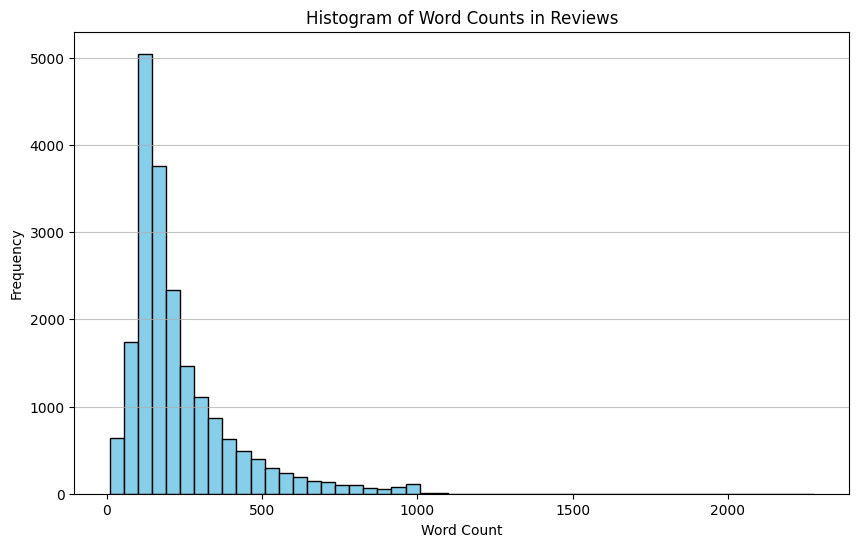

In [ ]:
import matplotlib.pyplot as plt
# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.hist(word_count, bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Word Counts in Reviews')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

Majority of reviews have less than 500 words.   
If needed in future, the reviews could be truncated  
upto a length of 500, to reduce computation.

We could see HTML break tags in the second review, before dropping entries.  
It will be a safe bet to remove all such tags from the reviews.  
We achieve this using regular expressions.

In [ ]:
def cleaning(text):
    text = text.lower()
    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

tqdm.pandas()
df['review'] = df['review'].progress_apply(cleaning)

I will use nltk's tokenizer since it is reliable and light weight as well.

In [ ]:
!pip install nltk

import nltk
nltk.download('punkt')

In [ ]:
from nltk.tokenize import word_tokenize

In [ ]:
tqdm.pandas()
df['review'] = df['review'].progress_apply(word_tokenize)

In [ ]:
df.head()

We can either train our own embeddings or use pre-trained ones.  
Here, I will be using GloVe for the word embeddings.  
For convenience, I have uploaded GloVe.6B.100d as an input.  
This will create 100-dimensional embeddings for each token.  
The below function presents the txt file in a format that  
can be used for embedding the tokens.


In [ ]:
def load_glove_embeddings(file_path):
    embeddings = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

glove_embeddings = load_glove_embeddings('/kaggle/input/glove6b100dtxt/glove.6B.100d.txt')
embedding_dim = 100

For each review, I will consider the first 500 tokens for embedding.  
If some review has less than 500 tokens, I will add some padding  
tokens to match the length.  
The embeddings and paddings are stored in padded_reviews.

In [ ]:
MAX_LEN = 500
padded_reviews = []

for tokens in tqdm(df['review'], desc='Embedding and Padding'):
    vectors = []
    for token in tokens[:MAX_LEN]:
        if token in glove_embeddings:
            vectors.append(glove_embeddings[token])
        else:
            vectors.append(np.zeros(embedding_dim))
    if len(vectors) < MAX_LEN:
        padding = np.zeros((MAX_LEN - len(vectors), embedding_dim))
        vectors = np.vstack((vectors, padding))
    else:
        vectors = np.array(vectors)
    padded_reviews.append(vectors)

In [ ]:
X = np.stack(padded_reviews)
y = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0).values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



---



$\LARGE \text{DATA LOADERS}$  
Pytorch is weird.

In [ ]:
from torch.utils.data import Dataset

class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

In [ ]:
from torch.utils.data import DataLoader

# Training Dataset and Loader
train_dataset = IMDBDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Test Dataset and Loader
test_dataset = IMDBDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

These loaders will be used in training and evaluation.



---



$\LARGE \text{ATTENTION CLASSES}$  
The different attentions have been explained in AttentionClasses.ipynb.  
In this notebook, I will only present the code, so that it can be imported into the models.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size, attn_size):
        super(BahdanauAttention, self).__init__()
        self.W1 = nn.Linear(hidden_size, attn_size)
        self.W2 = nn.Linear(hidden_size, attn_size)
        self.v = nn.Linear(attn_size, 1, bias=False)

    def forward(self, key, query):
        seq_len = key.size(1)
        query = query.unsqueeze(1).repeat(1, seq_len, 1)
        score = torch.tanh(self.W1(key) + self.W2(query))
        attention_weights = F.softmax(self.v(score).squeeze(-1), dim=1)
        context_vector = torch.bmm(attention_weights.unsqueeze(1), key).squeeze(1)

        return attention_weights, context_vector

class LuongDotAttention(nn.Module):
    def __init__(self):
        super(LuongDotAttention, self).__init__()

    def forward(self, key, query):
        query = query.unsqueeze(2)
        att_scores = torch.bmm(key, query).squeeze(2)
        att_weights = F.softmax(att_scores, dim=1)
        context_vector = torch.bmm(att_weights.unsqueeze(1), key).squeeze(1)

        return att_weights, context_vector

class LuongGeneralAttention(nn.Module):
    def __init__(self, hidden_size):
        super(LuongGeneralAttention, self).__init__()
        self.W = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, key, query):
        transformed_key = self.W(key)
        query = query.unsqueeze(2)
        att_scores = torch.bmm(transformed_key, query).squeeze(2)
        att_weights = F.softmax(att_scores, dim=1)
        context_vector = torch.bmm(att_weights.unsqueeze(1), key).squeeze(1)

        return att_weights, context_vector

class LuongConcatAttention(nn.Module):
    def __init__(self, hidden_size, attn_size):
        super(LuongConcatAttention, self).__init__()
        self.W = nn.Linear(2 * hidden_size, attn_size)
        self.v = nn.Linear(attn_size, 1, bias=False)

    def forward(self, key, query):
        batch_size, seq_len, hidden_size = key.size()
        query = query.unsqueeze(1).repeat(1, seq_len, 1)
        concat_matrix = torch.cat((key, query), dim=2)
        scores = torch.tanh(self.W(concat_matrix))
        att_scores = self.v(scores).squeeze(2)
        att_weights = F.softmax(att_scores, dim=1)
        context_vector = torch.bmm(att_weights.unsqueeze(1), key).squeeze(1)

        return att_weights, context_vector



---



$\LARGE \text{PLANS FOR AHEAD}$  
I will make a sentiment analyzer, using 4 architectures:-  
RNNS and LSTMS (both unidirectional and bidirectional).  
After this, we will compare each architecture's performance with all the 4  
kinds of attention layers. So, a total of 20 models !!!  
Clearly, things can get a bit messy from here on, so I am defining functions  
for training and evaluating below. I will keep reusing them.  
Evaluation for each model is presented in Report.ipynb

$\large \text{TRAINING FUNCTION}$

In [ ]:
def training(model):
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model = model.to(device)
  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

  EPOCHS = 100

  for epoch in range(EPOCHS):
      model.train()
      total_loss = 0

      for inputs, labels in train_loader:
          inputs = inputs.to(device)
          labels = labels.to(device)
          optimizer.zero_grad()

          if isinstance(model, AttentionRNNClassifier) or isinstance(model, AttentionLSTMClassifier):
            outputs, _ = model(inputs)
          else:
            outputs = model(inputs)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()

          total_loss += loss.item()

      if (epoch+1)%10==0:
          print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader):.4f}')

$\large \text{EVALUATION FUNCTION}$

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
def evaluation(model):
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model = model.to(device)
  model.eval()
  all_preds = []
  all_labels = []

  with torch.no_grad():
      for inputs, labels in test_loader:
          inputs = inputs.to(device)
          labels = labels.to(device)

          if isinstance(model, AttentionRNNClassifier) or isinstance(model, AttentionLSTMClassifier):
            outputs, _ = model(inputs)
          else:
            outputs = model(inputs)
          _, preds = torch.max(outputs, 1)

          all_preds.extend(preds.cpu().numpy())
          all_labels.extend(labels.cpu().numpy())

  accuracy = accuracy_score(all_labels, all_preds)
  print(f'Test Accuracy: {accuracy:.4f}')

  print("Classification Report:")
  print(classification_report(all_labels, all_preds, target_names=['negative', 'positive']))

  cm = confusion_matrix(all_labels, all_preds)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'positive'])

  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix')
  plt.show()



---



$\LARGE \text{UNIDIRECTIONAL RNN}$

In [ ]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size=100, hidden_size=128, num_layers=1, num_classes=2):
        super(RNNClassifier, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        # take the output from the last time step
        out = out[:, -1]
        out = self.fc(out)
        return out

In [ ]:
# before running this cell, run the one that is below it
# or else the code will throw an error.
# training function checks for the type of the model.
# if we dont run the AttentionRNNClassifier class,
# isintance(AttentionRNNClassifier) will be left undefined, which
# will throw the error.
# similar precautions should be followed for running other models
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RNNClassifier().to(device)
training(model)
evaluation(model)

In [ ]:
class AttentionRNNClassifier(nn.Module):
    def __init__(self, input_size=100, hidden_size=64, num_classes=2, attn_type='dot', num_layers=10):
        super(AttentionRNNClassifier, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers, batch_first=True)

        if attn_type == 'bahdanau':
            self.attention = BahdanauAttention(hidden_size, attn_size=64)
        elif attn_type == 'dot':
            self.attention = LuongDotAttention()
        elif attn_type == 'general':
            self.attention = LuongGeneralAttention(hidden_size)
        elif attn_type == 'concat':
            self.attention = LuongConcatAttention(hidden_size, attn_size=64)

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, hidden = self.rnn(x)
        hidden = hidden[-1]
        attn_weights, context = self.attention(out, hidden)
        output = self.fc(context)

        return output, attn_weights

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AttentionRNNClassifier().to(device)
training(model)
evaluation(model)



---



$\LARGE \text{BIDIRECTIONAL RNN}$

In [ ]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size=100, hidden_size=64, num_layers=1, num_classes=2):
        super(RNNClassifier, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(2*hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1]
        out = self.fc(out)
        return out

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RNNClassifier().to(device)
training(model)
evaluation(model)

In [ ]:
class AttentionRNNClassifier(nn.Module):
    def __init__(self, input_size=100, hidden_size=64, num_classes=2, attn_type='bahdanau', num_layers=1):
        super(AttentionRNNClassifier, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers, batch_first=True, bidirectional=True)

        if attn_type == 'bahdanau':
            self.attention = BahdanauAttention(2*hidden_size, attn_size=64)
        elif attn_type == 'dot':
            self.attention = LuongDotAttention()
        elif attn_type == 'general':
            self.attention = LuongGeneralAttention(2*hidden_size)
        elif attn_type == 'concat':
            self.attention = LuongConcatAttention(2*hidden_size, attn_size=64)

        self.fc = nn.Linear(2*hidden_size, num_classes)

    def forward(self, x):
        out, hidden = self.rnn(x)
        hidden = hidden[-1]
        attn_weights, context = self.attention(out, hidden)
        output = self.fc(context)

        return output, attn_weights

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AttentionRNNClassifier().to(device)
training(model)
evaluation(model)



---



$\LARGE \text{UNIDIRECTIONAL LSTM}$  

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=100, hidden_size=128, num_layers=1, num_classes=2):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1]
        out = self.fc(out)
        return out

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMClassifier().to(device)
training(model)
evaluation(model)

In [ ]:
class AttentionLSTMClassifier(nn.Module):
    def __init__(self, input_size=100, hidden_size=128, num_classes=2, attn_type='concat', num_layers=1):
        super(AttentionLSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)

        if attn_type == 'bahdanau':
            self.attention = BahdanauAttention(hidden_size, attn_size=64)
        elif attn_type == 'dot':
            self.attention = LuongDotAttention()
        elif attn_type == 'general':
            self.attention = LuongGeneralAttention(hidden_size)
        elif attn_type == 'concat':
            self.attention = LuongConcatAttention(hidden_size, attn_size=64)

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, (hidden,cell) = self.lstm(x)
        hidden = hidden[-1]
        attn_weights, context = self.attention(out, hidden)
        output = self.fc(context)

        return output, attn_weights

In [ ]:
model = AttentionLSTMClassifier().to(device)
training(model)
evaluation(model)



---



$\LARGE \text{BIDIRECTIONAL LSTM}$

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=100, hidden_size=128, num_layers=1, num_classes=2):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.bidirectional = True

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(2*hidden_size, num_classes)

    def forward(self, x):
        out, (hidden, cell) = self.lstm(x)
        # get the last hidden state from both directions
        forward_hidden = hidden[-2]  # last layer forward hidden state
        backward_hidden = hidden[-1]  # last layer backward hidden state
        combined_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)
        output = self.fc(combined_hidden)

        return output

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMClassifier().to(device)
training(model)
evaluation(model)

In [ ]:
class AttentionLSTMClassifier(nn.Module):
    def __init__(self, input_size=100, hidden_size=64, num_classes=2, attn_type='general', num_layers=1):
        super(AttentionLSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.bidirectional = True
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, bidirectional=True)

        if attn_type == 'bahdanau':
            self.attention = BahdanauAttention(2*hidden_size, attn_size=64)
        elif attn_type == 'dot':
            self.attention = LuongDotAttention()
        elif attn_type == 'general':
            self.attention = LuongGeneralAttention(2*hidden_size)
        elif attn_type == 'concat':
            self.attention = LuongConcatAttention(2*hidden_size, attn_size=64)

        self.fc = nn.Linear(2*hidden_size, num_classes)

    def forward(self, x):
        out, (hidden, cell) = self.lstm(x)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        combined_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)
        attn_weights, context = self.attention(out, combined_hidden)
        output = self.fc(context)

        return output, attn_weights

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AttentionLSTMClassifier().to(device)
training(model)
evaluation(model)

The models have been evaluated in Report.ipynb